# 03. CP2: моделирование, эксперименты и выбор финальной модели

В CP2 используем engineered-признаки поверх Portugal subset: статистики по 13 Sentinel-2 каналам, месячные агрегаты и спектральные индексы NDVI/NDWI/NBR. Эксперименты воспроизводятся командой `python -m src.experiments` или `make experiments`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPORT_DIR = ROOT / "report"
IMAGES_DIR = REPORT_DIR / "images"
sns.set_theme(style="whitegrid", context="notebook")

## Подготовленные признаки

Файл `data/processed/portugal_engineered_features.npz` не коммитится, но воспроизводится из raw Portugal parquet командой `python -m src.features`. Внутри сохранены `X`, `y`, `feature_names` и индексы единого train/validation/test split.

Признаки:

- per-band статистики: mean, std, min, max, median, q25, q75, iqr, range;
- monthly mean по каждому каналу;
- valid observation count, missing rate, zero share;
- NDVI/NDWI/NBR статистики по стандартному порядку Sentinel-2 каналов.

In [2]:
summary = pd.read_json(REPORT_DIR / "cp2_summary.json", typ="series")
summary

best_validation_model       extra_trees_80_half_features
best_validation_macro_f1                        0.185177
best_test_macro_f1                              0.191078
best_test_accuracy                              0.556784
seed                                                  42
n_train                                            59989
n_val                                              19997
n_test                                             19997
n_features                                           288
dtype: object

## Таблица экспериментов

Сравниваем dummy baseline, линейные модели, деревья, gradient boosting, PCA-вариант и hard-voting ensemble. Основная метрика — validation/test macro F1, потому что классы сильно несбалансированы.

In [3]:
experiments = pd.read_csv(REPORT_DIR / "experiments.csv")
experiments.sort_values(["split", "macro_f1"], ascending=[True, False])

,model,feature_set,split,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,extra_trees_80_half_features,raw_engineered,test,0.556784,0.173364,0.191078,0.521149
1,extra_trees_80_sqrt,raw_engineered,test,0.534180,0.156949,0.170610,0.498523
2,random_forest_60_sqrt,raw_engineered,test,0.541731,0.140958,0.154259,0.500408
3,voting_ensemble,raw_engineered,test,0.530680,0.188861,0.145760,0.514313
4,hist_gradient_boosting_lr_0.05,raw_engineered,test,0.541431,0.133693,0.134641,0.495223
5,hist_gradient_boosting_lr_0.10,raw_engineered,test,0.530230,0.141990,0.123394,0.502724
6,sgd_logistic_alpha_1e-4,raw_engineered,test,0.442216,0.139358,0.109326,0.445111
7,ridge_alpha_1,raw_engineered,test,0.151123,0.271435,0.075100,0.189139
8,ridge_alpha_10,raw_engineered,test,0.145772,0.269621,0.072654,0.181558
9,pca50_ridge_alpha_1,pca_50,test,0.057309,0.163219,0.037296,0.064990


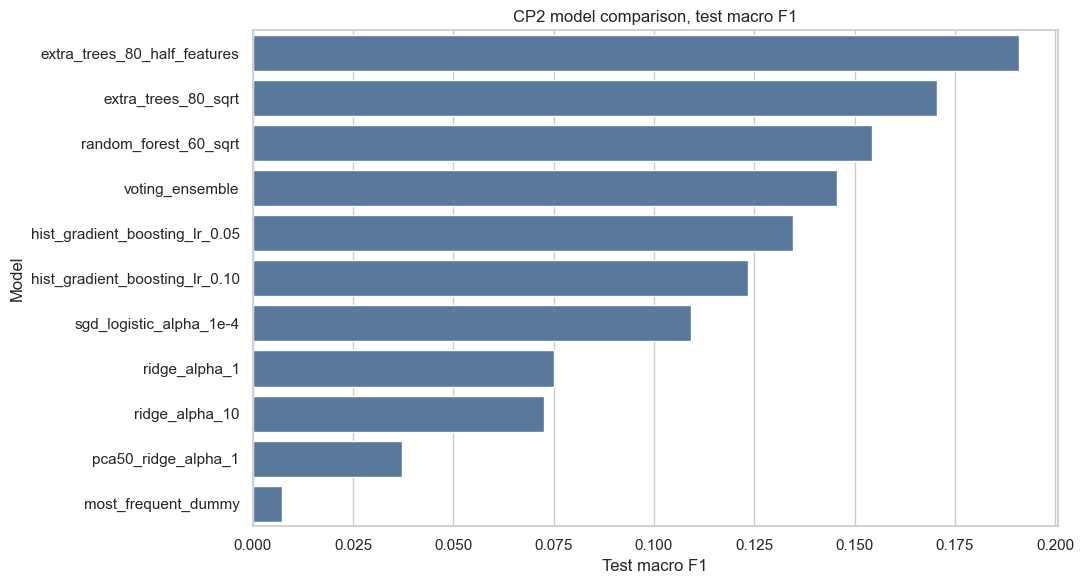

In [4]:
test_results = experiments[experiments["split"] == "test"].sort_values("macro_f1", ascending=False)
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=test_results, x="macro_f1", y="model", ax=ax, color="#4c78a8")
ax.set_title("CP2 model comparison, test macro F1")
ax.set_xlabel("Test macro F1")
ax.set_ylabel("Model")
plt.tight_layout()
fig.savefig(IMAGES_DIR / "cp2_experiment_metrics.png", dpi=160, bbox_inches="tight")
plt.show()

## Значимость признаков

ANOVA F-score считается на train split. Этот анализ закрывает замечание CP1: теперь есть не только описание исходных фичей, но и оценка связи engineered-признаков с целевой переменной.

,feature,f_score,p_value
0,B04_median,263.870325,0.0
1,B03_median,260.499714,0.0
2,B03_q25,242.576036,0.0
3,B08_q25,224.728468,0.0
4,B08_median,217.625186,0.0
5,B04_q25,205.192613,0.0
6,B12_median,191.011875,0.0
7,B08_month_07_mean,179.415143,0.0
8,valid_observation_count,166.681968,0.0
9,missing_rate,166.641330,0.0


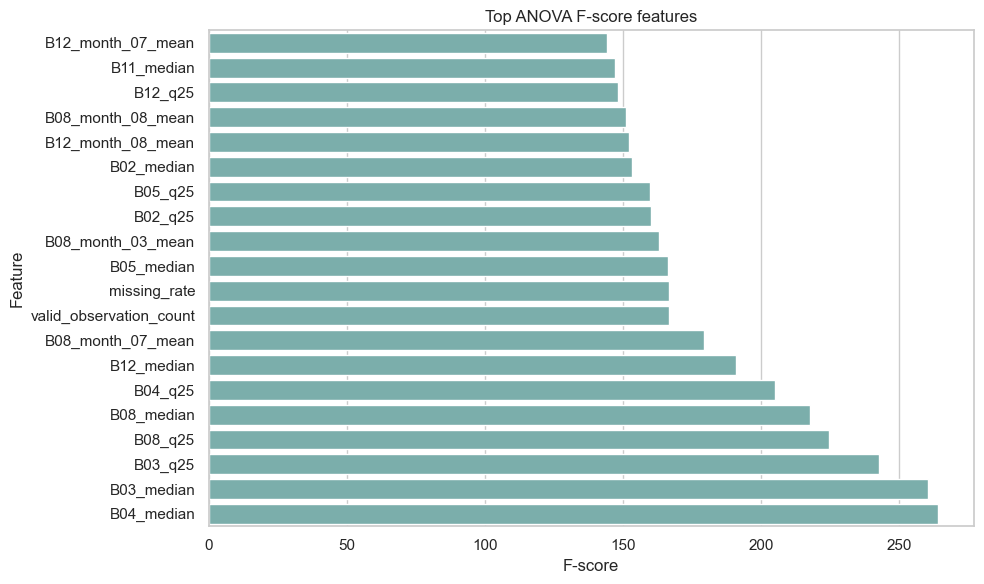

In [5]:
feature_scores = pd.read_csv(REPORT_DIR / "feature_scores.csv")
display(feature_scores.head(20))

fig, ax = plt.subplots(figsize=(10, 6))
top_scores = feature_scores.head(20).sort_values("f_score")
sns.barplot(data=top_scores, x="f_score", y="feature", ax=ax, color="#72b7b2")
ax.set_title("Top ANOVA F-score features")
ax.set_xlabel("F-score")
ax.set_ylabel("Feature")
plt.tight_layout()
fig.savefig(IMAGES_DIR / "cp2_feature_scores.png", dpi=160, bbox_inches="tight")
plt.show()

## Уменьшение размерности

Для критерия dimensionality reduction проведён эксперимент `pca50_ridge_alpha_1`: `StandardScaler -> PCA(50) -> RidgeClassifier`. Также построены графики 2D PCA projection и explained variance. PCA сильно сжимает признаки, но качество ниже, чем у деревьев на полных engineered-признаках, поэтому PCA не выбран для финальной модели.

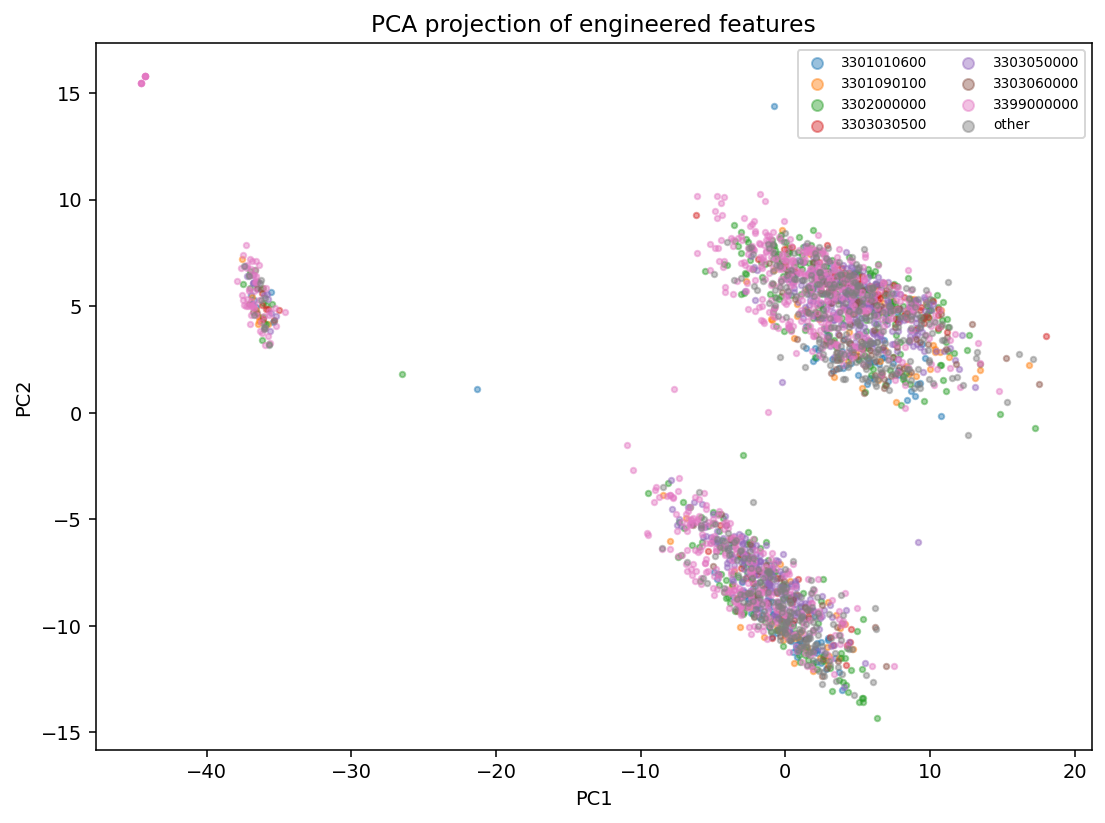

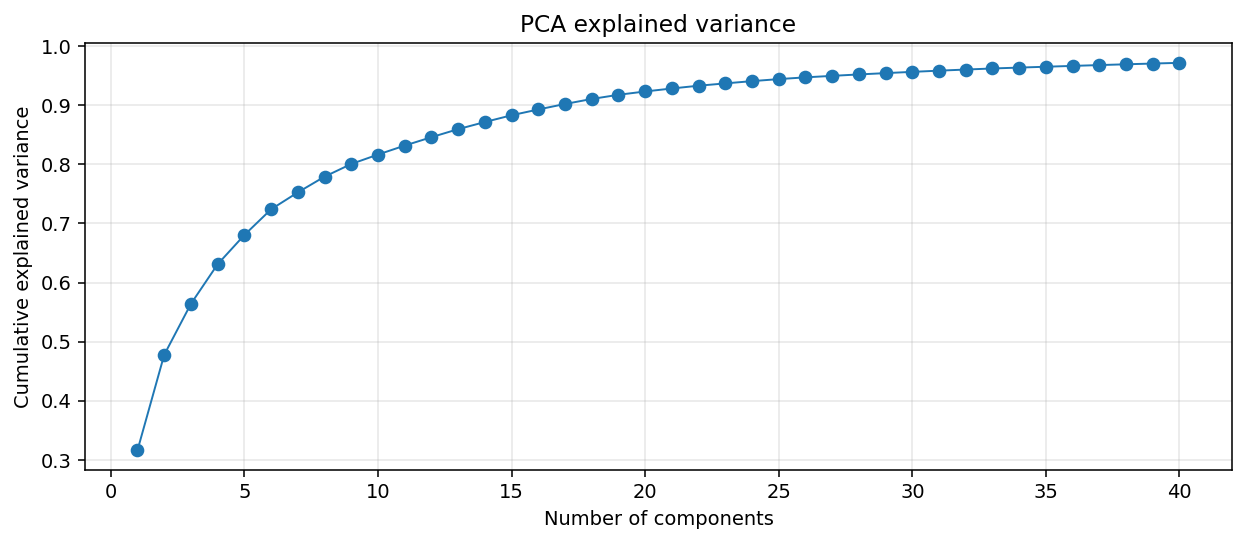

In [6]:
from IPython.display import Image, display

for image_name in ["cp2_pca_projection.png", "cp2_pca_variance.png"]:
    display(Image(filename=str(IMAGES_DIR / image_name)))

## Выбор финальной модели

Финальная модель по validation macro F1 — `extra_trees_80_half_features`. На test она получает macro F1 около 0.191 и accuracy около 0.557, что заметно лучше CP1 baseline (`macro F1 ≈ 0.126`) и dummy (`macro F1 ≈ 0.007`).

Почему выбран ExtraTrees:

- лучшая validation macro F1 среди проверенных моделей;
- хорошо работает с нелинейными зависимостями в агрегированных временных признаках;
- не требует масштабирования признаков;
- даёт feature importance для интерпретации.

Ограничение: macro F1 всё ещё невысокий из-за 66 классов после фильтрации, сильного дисбаланса и очень редких культур. Следующий шаг — более аккуратная работа с иерархией `EC_hcat_c`, class grouping и специализированные модели временных рядов.